# Step 5: Prediction Interpretation & Business Mapping
**FreshGuard ML Pipeline**

> *AI predicts expiry risk; business rules decide actions.*

The ML model outputs **expiry probability** first. Then the system derives **sell-through-before-expiry probability** and applies business rules after prediction.


## 5.1 ML Output: Expiry Probability and Sell-Through Probability

| Value | Meaning |
|---|---|
| `expiry_probability = 0.85` | 85% chance this batch expires before being fully sold |
| `sell_through_before_expiry_probability = 0.15` | 15% chance it will sell out in time |

The business-facing probability is derived as:

`1 - expiry_probability`

This keeps the ML target and the dashboard wording consistent.


## 5.2 Business Mapping (Rule-based, AFTER ML)

Rules consume ML output — they do **not** replace ML.

| ML Probability | Risk Level | System Action |
|---|---|---|
| > 0.70 | HIGH | Alert + discount suggestion |
| 0.40 - 0.70 | MEDIUM | Warning notification |
| < 0.40 | LOW | No action needed |

Loaded model and datasets.
=== Sample Probability Scores ===
  product_name        category  days_until_expiry  units_sold  initial_quantity  expiry_probability  sell_through_before_expiry_probability risk_level
        Donuts          Bakery                  2         138               158              0.9800                                  0.0200       HIGH
      Sausages            Meat                  4         251               353              0.9967                                  0.0033       HIGH
        Bagels          Bakery                  0         483               483              0.9733                                  0.0267       HIGH
      Vaccines Pharmaceuticals                 79         477               477              0.0667                                  0.9333        LOW
   Fresh Pasta    Ready_to_Eat                  3         391               391              0.0267                                  0.9733        LOW
     Eye Drops Pharmaceuticals   

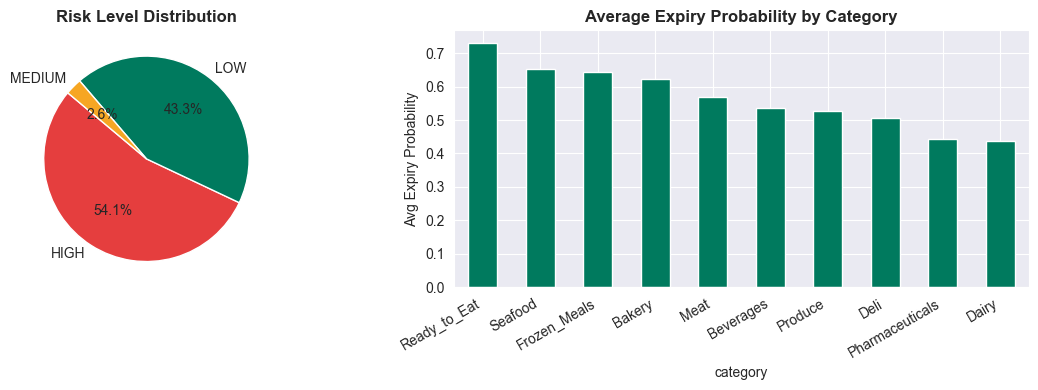

Predictions saved: (100000, 12)
 product_id   product_name        category  days_until_expiry  initial_quantity  units_sold  remaining_quantity  expiry_probability  sell_through_before_expiry_probability risk_level  suggested_discount_pct                                               action
BAK_DON_743         Donuts          Bakery                  2               158         138                  20              0.9800                                  0.0200       HIGH                      30 ALERT: Show dashboard alert and suggest 30% discount
MEA_SAU_338       Sausages            Meat                  4               353         251                 102              0.9967                                  0.0033       HIGH                      30 ALERT: Show dashboard alert and suggest 30% discount
BAK_BAG_799         Bagels          Bakery                  0               483         483                   0              0.9733                                  0.0267       HIGH      

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os, json, warnings
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

with open('outputs/feature_list.json') as f:
    meta = json.load(f)
FEATURES = meta['features']

rf_model = joblib.load('outputs/random_forest_model.pkl')
df_feat = pd.read_csv('outputs/feature_dataset.csv')
df_orig = pd.read_csv('outputs/cleaned_dataset.csv')
print('Loaded model and datasets.')

X_all = df_feat[FEATURES]

# Model predicts expiry probability
df_orig['expiry_probability'] = rf_model.predict_proba(X_all)[:, 1]

# Business-facing probability
df_orig['sell_through_before_expiry_probability'] = 1 - df_orig['expiry_probability']

df_orig['expiry_probability'] = df_orig['expiry_probability'].round(4)
df_orig['sell_through_before_expiry_probability'] = df_orig['sell_through_before_expiry_probability'].round(4)

def classify_risk(expiry_prob):
    if expiry_prob > 0.70:
        return 'HIGH'
    elif expiry_prob >= 0.40:
        return 'MEDIUM'
    return 'LOW'

def suggested_discount(expiry_prob):
    if expiry_prob > 0.70:
        return 30
    elif expiry_prob >= 0.40:
        return 15
    return 0

def suggest_action(expiry_prob):
    if expiry_prob > 0.70:
        return 'ALERT: Show dashboard alert and suggest 30% discount'
    elif expiry_prob >= 0.40:
        return 'WARNING: Monitor closely and consider 15% discount'
    return 'OK: No action needed'

df_orig['risk_level'] = df_orig['expiry_probability'].apply(classify_risk)
df_orig['suggested_discount_pct'] = df_orig['expiry_probability'].apply(suggested_discount)
df_orig['action'] = df_orig['expiry_probability'].apply(suggest_action)

print('=== Sample Probability Scores ===')
sample = df_orig[
    [
        'product_name',
        'category',
        'days_until_expiry',
        'units_sold',
        'initial_quantity',
        'expiry_probability',
        'sell_through_before_expiry_probability',
        'risk_level'
    ]
].head(10)
print(sample.to_string(index=False))

print('=== Risk Level Distribution ===')
print(df_orig['risk_level'].value_counts())

print('=== High Risk Products (Top 15) ===')
high_risk = df_orig[df_orig['risk_level'] == 'HIGH'].sort_values('expiry_probability', ascending=False)
print(
    high_risk[
        [
            'product_name',
            'category',
            'days_until_expiry',
            'expiry_probability',
            'sell_through_before_expiry_probability',
            'suggested_discount_pct',
            'action'
        ]
    ].head(15).to_string(index=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

risk_counts = df_orig['risk_level'].value_counts()
colors_map = {'HIGH': '#E53E3E', 'MEDIUM': '#F6A623', 'LOW': '#007A5E'}
axes[0].pie(
    risk_counts,
    labels=risk_counts.index,
    colors=[colors_map[label] for label in risk_counts.index],
    autopct='%1.1f%%',
    startangle=140
)
axes[0].set_title('Risk Level Distribution', fontweight='bold')

cat_prob = df_orig.groupby('category')['expiry_probability'].mean().sort_values(ascending=False)
cat_prob.plot(kind='bar', ax=axes[1], color='#007A5E', edgecolor='white')
axes[1].set_title('Average Expiry Probability by Category', fontweight='bold')
axes[1].set_ylabel('Avg Expiry Probability')
axes[1].set_xticklabels(cat_prob.index, rotation=30, ha='right')

plt.tight_layout()
plt.savefig('outputs/risk_mapping.png', dpi=120, bbox_inches='tight')
plt.show()

if 'remaining_quantity' not in df_orig.columns:
    df_orig['remaining_quantity'] = (df_orig['initial_quantity'] - df_orig['units_sold']).clip(lower=0)

out_cols = [
    'product_id',
    'product_name',
    'category',
    'days_until_expiry',
    'initial_quantity',
    'units_sold',
    'remaining_quantity',
    'expiry_probability',
    'sell_through_before_expiry_probability',
    'risk_level',
    'suggested_discount_pct',
    'action'
]

df_predictions = df_orig[out_cols].copy()
df_predictions.to_csv('outputs/predictions_with_actions.csv', index=False)

print(f'Predictions saved: {df_predictions.shape}')
print(df_predictions.head(10).to_string(index=False))


## Summary

**ML Output:**
- `expiry_probability` = model prediction for `expire_before_sold`

**Derived Business Output:**
- `sell_through_before_expiry_probability = 1 - expiry_probability`

**Business Rules:**
- `> 0.70` expiry probability -> HIGH risk -> alert + 30% suggestion
- `0.40 to 0.70` -> MEDIUM risk -> monitor + 15% suggestion
- `< 0.40` -> LOW risk -> no action needed
